<a href="https://colab.research.google.com/github/JaySharma424/Data-Science/blob/main/Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b> The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX - nitric oxides concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built prior to 1940
* DIS - weighted distances to five Boston employment centres
* RAD - index of accessibility to radial highways
* TAX - full-value property-tax rate per \$10,000
* PTRATIO - pupil-teacher ratio by town
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT - % lower status of the population
* MEDV - Median value of owner-occupied homes in $1000's

## <b>MEDV is the dependent variable.

## Fit polynomial regression on this dataset for degrees 1 to 10. To do such a regression, consider only one variable and then run polynomial fit and plot the train and test errors w.r.t model complexity. You can also repeat this experiment for all the other variables. Also do not use <code>np.polyfit</code>function, but use the <code>LinearRegression()</code> using the scikit-learn library.</b>

In [418]:
#import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [419]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [420]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/Machine_Learning/housing.csv')

In [421]:
df.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6


In [422]:
df.describe(include='all')

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


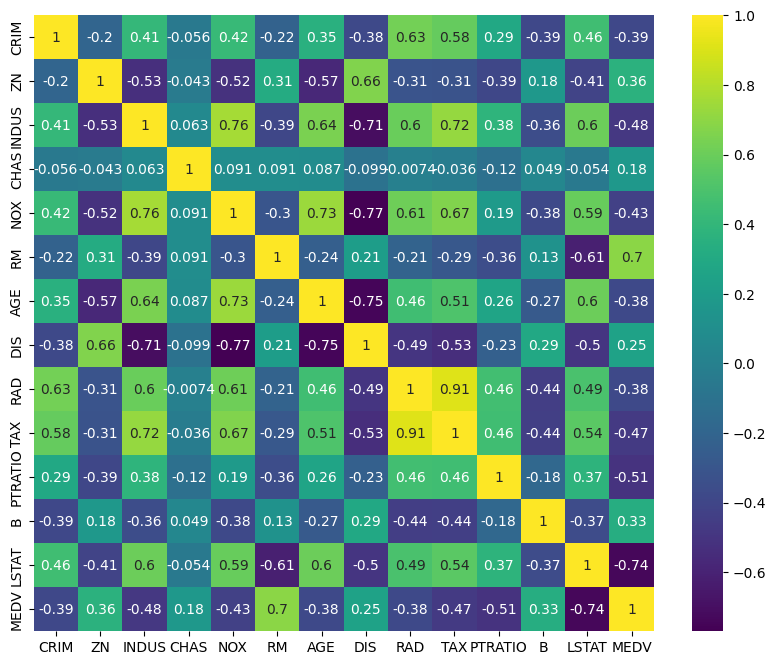

In [423]:
#lets see the corelation on heatmap
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='viridis')
plt.show()

In [424]:
df.columns.tolist()

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [425]:
# declearing dependent and independent varible for the traning and testing

Independent_var = df.drop('MEDV',axis=1)
Dependent_var = df['MEDV']

In [426]:
# Empty list for storing training and testing error and mse_error
train_error = []
test_error = []

In [427]:
#Fit polynomial regression on dataset for degrees 1 to 10.
#consider only one variable at a time and then run polynomial and store mse, train and test error in a list

list_index = 0
for feature in Independent_var.columns:
  X_train, X_test, y_train, y_test = train_test_split(df[feature],Dependent_var,test_size=.2,random_state=0)
  train_error.append([])
  test_error.append([])
  for degree_value in range(1,11):
    poly = PolynomialFeatures(degree = degree_value)
    X_poly_train = poly.fit_transform(pd.DataFrame(X_train))
    lin = LinearRegression()
    lin.fit(X_poly_train,y_train)
    y_train_predicted = lin.predict(X_poly_train)
    train_error[list_index].append(root_mean_squared_error(y_train,y_train_predicted))
    X_poly_test = poly.fit_transform(pd.DataFrame(X_test))
    # test_error[list_index].append(lin.score(X_poly_test,y_test))
    y_poly_test_pred = lin.predict(X_poly_test)
    test_error[list_index].append(root_mean_squared_error(y_test,y_poly_test_pred))



  list_index += 1


In [428]:
len(train_error)

13

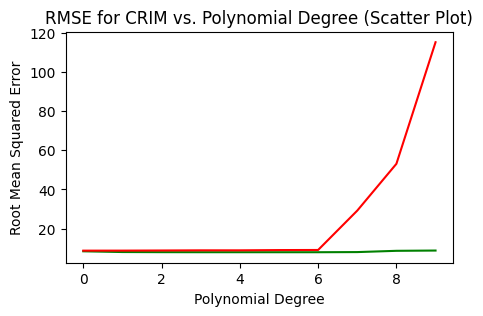

In [429]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[0],color='green',label='Train_Error')
plt.plot(test_error[0],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for CRIM vs. Polynomial Degree (Scatter Plot)')
plt.show()

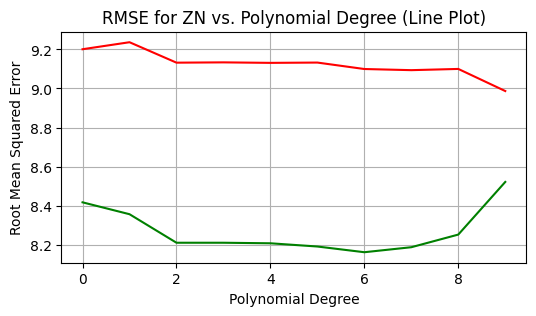

In [430]:
plt.figure(figsize=(6, 3))
plt.plot(train_error[1],color='green',label='Train_Error')
plt.plot(test_error[1],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for ZN vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

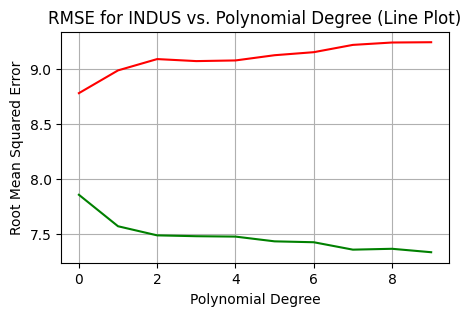

In [431]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[2],color='green',label='Train_Error')
plt.plot(test_error[2],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for INDUS vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

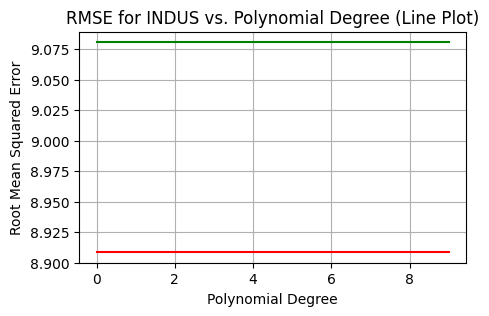

In [432]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[3],color='green',label='Train_Error')
plt.plot(test_error[3],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for INDUS vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

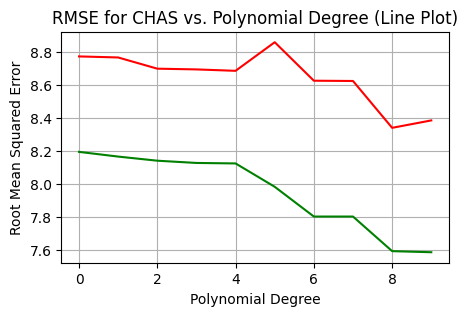

In [433]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[4],color='green',label='Train_Error')
plt.plot(test_error[4],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for CHAS vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

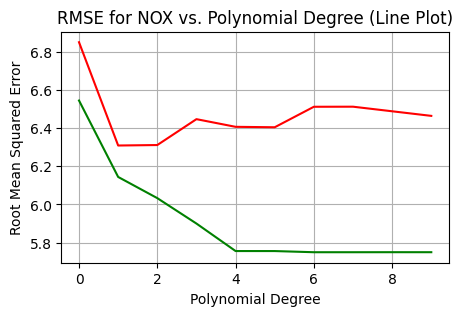

In [434]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[5],color='green',label='Train_Error')
plt.plot(test_error[5],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for NOX vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

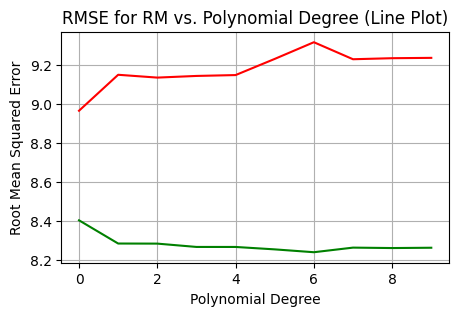

In [435]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[6],color='green',label='Train_Error')
plt.plot(test_error[6],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for RM vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

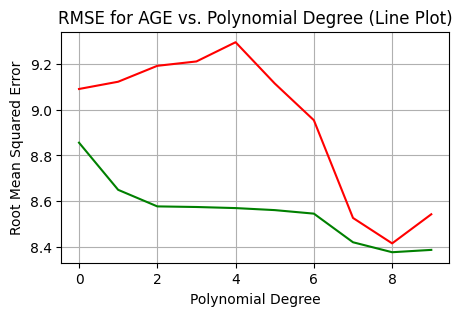

In [436]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[7],color='green',label='Train_Error')
plt.plot(test_error[7],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for AGE vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

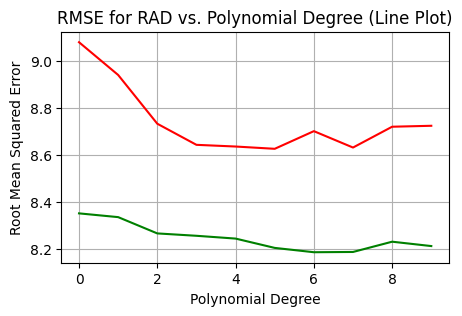

In [437]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[8],color='green',label='Train_Error')
plt.plot(test_error[8],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for RAD vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

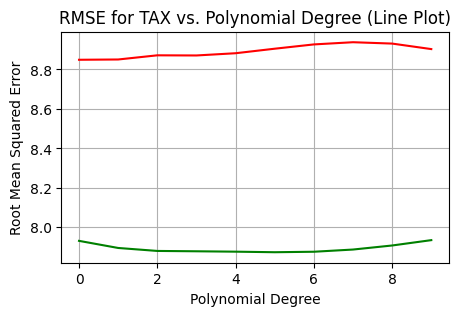

In [438]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[9],color='green',label='Train_Error')
plt.plot(test_error[9],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for TAX vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

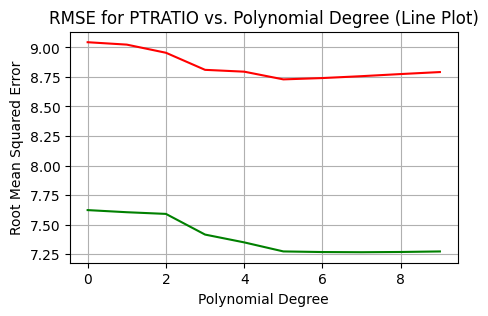

In [439]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[10],color='green',label='Train_Error')
plt.plot(test_error[10],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for PTRATIO vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

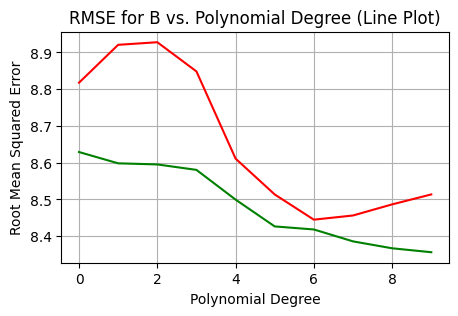

In [440]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[11],color='green',label='Train_Error')
plt.plot(test_error[11],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for B vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()

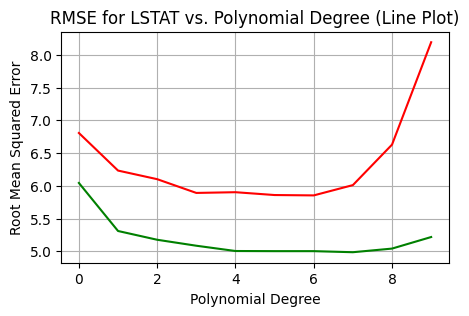

In [441]:
plt.figure(figsize=(5, 3))
plt.plot(train_error[12],color='green',label='Train_Error')
plt.plot(test_error[12],color='red',label='Test_Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error')
plt.title('RMSE for LSTAT vs. Polynomial Degree (Line Plot)')
plt.grid(True)
plt.show()